In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8


In [2]:
orders = pd.read_csv('../Data/raw_data/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
reviews = pd.read_csv('../Data/raw_data/olist_order_reviews_dataset.csv')

delivered = orders[orders['order_status'] == 'delivered'].copy()
df = delivered.merge(reviews[['order_id', 'review_score']], on='order_id')
df = df.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score'])

df['is_delayed'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
df['delivery_status'] = df['is_delayed'].map({True: 'Delayed', False: 'On-Time / Early'})
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

print(f"Total delivered orders analyzed : {len(df):,}")
print(f"Delayed orders count             : {df['is_delayed'].sum():,} ({df['is_delayed'].mean()*100:.2f}%)")
print(f"On-time / early orders count     : {(~df['is_delayed']).sum():,} ({(~df['is_delayed']).mean()*100:.2f}%)")
df[['order_id', 'delivery_days', 'delay_days', 'is_delayed', 'delivery_status', 'review_score']].head()


Total delivered orders analyzed : 96,353
Delayed orders count             : 7,700 (7.99%)
On-time / early orders count     : 88,653 (92.01%)


In [3]:
delayed = df[df['is_delayed'] == True]['review_score']
ontime = df[df['is_delayed'] == False]['review_score']

summary_table = pd.DataFrame({
    'Cohort': ['On-Time / Early', 'Delayed Orders'],
    'Sample Size (N)': [len(ontime), len(delayed)],
    'Mean Score': [ontime.mean(), delayed.mean()],
    'Median Score': [ontime.median(), delayed.median()],
    'Std Deviation': [ontime.std(), delayed.std()],
    '1-Star Review %': [(ontime == 1).mean() * 100, (delayed == 1).mean() * 100],
    '5-Star Review %': [(ontime == 5).mean() * 100, (delayed == 5).mean() * 100]
}).round(3)

print("=" * 70)
print("COHORT DESCRIPTIVE SUMMARY STATISTICS")
print("=" * 70)
print(summary_table.to_string(index=False))


COHORT DESCRIPTIVE SUMMARY STATISTICS
         Cohort  Sample Size (N)  Mean Score  Median Score  Std Deviation  1-Star Review %  5-Star Review %
On-Time / Early            88653       4.294           5.0          1.148            6.600           62.432
 Delayed Orders             7700       2.566           2.0          1.658           46.156           22.221


In [4]:
t_stat, p_value = stats.ttest_ind(delayed, ontime, equal_var=False)

n1, n2 = len(delayed), len(ontime)
s1, s2 = np.var(delayed, ddof=1), np.var(ontime, ddof=1)
s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
cohens_d = (delayed.mean() - ontime.mean()) / s_pooled

print("=" * 55)
print("TWO-SAMPLE WELCH'S T-TEST RESULTS")
print("=" * 55)
print(f"Delayed Orders  — Mean Score: {delayed.mean():.3f} (n = {len(delayed):,})")
print(f"On-Time Orders  — Mean Score: {ontime.mean():.3f} (n = {len(ontime):,})")
print(f"Difference in Means         : {delayed.mean() - ontime.mean():.3f} stars")
print(f"T-Statistic                 : {t_stat:.4f}")
print(f"P-Value                     : {p_value:.2e}")
print(f"Cohen's d (Effect Size)     : {cohens_d:.4f}")

if p_value < 0.05:
    print("\n✅ REJECT H₀: Delivery delay SIGNIFICANTLY lowers review scores! (p < 0.05)")
    print(f"   Effect size (|d| = {abs(cohens_d):.2f}) indicates an extremely LARGE practical impact.")
else:
    print("\n❌ FAIL TO REJECT H₀")


TWO-SAMPLE WELCH'S T-TEST RESULTS
Delayed Orders  — Mean Score: 2.566 (n = 7,700)
On-Time Orders  — Mean Score: 4.294 (n = 88,653)
Difference in Means         : -1.727 stars
T-Statistic                 : -89.5507
P-Value                     : 0.00e+00
Cohen's d (Effect Size)     : -1.4435

✅ REJECT H₀: Delivery delay SIGNIFICANTLY lowers review scores! (p < 0.05)
   Effect size (|d| = 1.44) indicates an extremely LARGE practical impact.


In [5]:
u_stat, u_p_val = stats.mannwhitneyu(delayed, ontime, alternative='less')

contingency_table = pd.crosstab(df['delivery_status'], df['review_score'])
contingency_table = contingency_table.reindex(['On-Time / Early', 'Delayed'])
chi2, chi2_p, dof, _ = stats.chi2_contingency(contingency_table)

print("=" * 55)
print("ROBUSTNESS CHECKS: MANN-WHITNEY U & CHI-SQUARE")
print("=" * 55)
print(f"Mann-Whitney U Statistic    : {u_stat:,.1f}")
print(f"Mann-Whitney P-Value        : {u_p_val:.2e}")
print(f"Chi-Square Statistic (χ²)   : {chi2:,.2f} (df={dof})")
print(f"Chi-Square P-Value          : {chi2_p:.2e}")

print("\nContingency Table (Review Score Frequencies):")
print(contingency_table)


ROBUSTNESS CHECKS: MANN-WHITNEY U & CHI-SQUARE
Mann-Whitney U Statistic    : 152,419,611.0
Mann-Whitney P-Value        : 0.00e+00
Chi-Square Statistic (χ²)   : 14,252.21 (df=4)
Chi-Square P-Value          : 0.00e+00

Contingency Table (Review Score Frequencies):
review_score        1     2     3      4      5
delivery_status                                
On-Time / Early  5851  2335  7086  18033  55348
Delayed          3554   606   875    954   1711


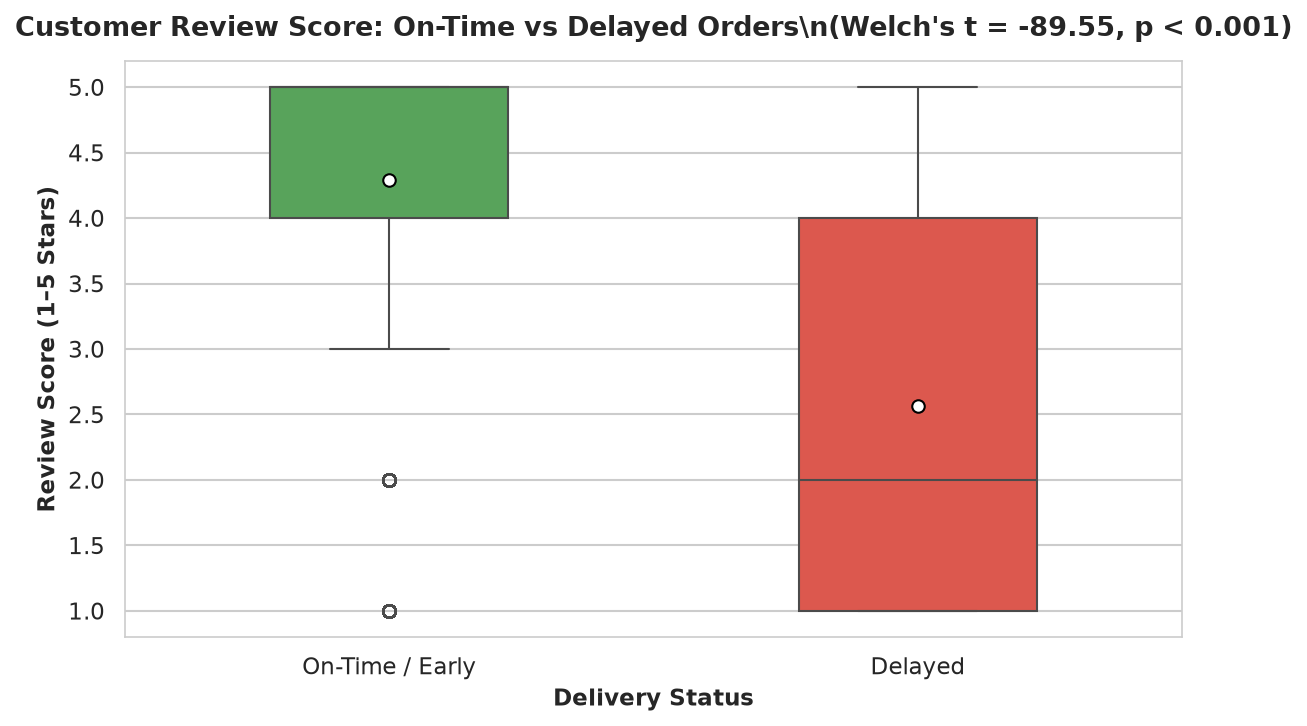

In [6]:
plt.figure(figsize=(8, 5))
palette = {'On-Time / Early': '#4CAF50', 'Delayed': '#F44336'}
sns.boxplot(x='delivery_status', y='review_score', data=df, order=['On-Time / Early', 'Delayed'],
            hue='delivery_status', palette=palette, legend=False, width=0.45, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title(f'Customer Review Score: On-Time vs Delayed Orders\n(Welch\'s t = {t_stat:.2f}, p < 0.001)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Delivery Status', fontsize=11, fontweight='bold')
plt.ylabel('Review Score (1–5 Stars)', fontsize=11, fontweight='bold')
plt.tight_layout()

plt.savefig('hypothesis_test.png', dpi=150)
plt.savefig('PNG/hypothesis_test.png', dpi=150)
plt.show()


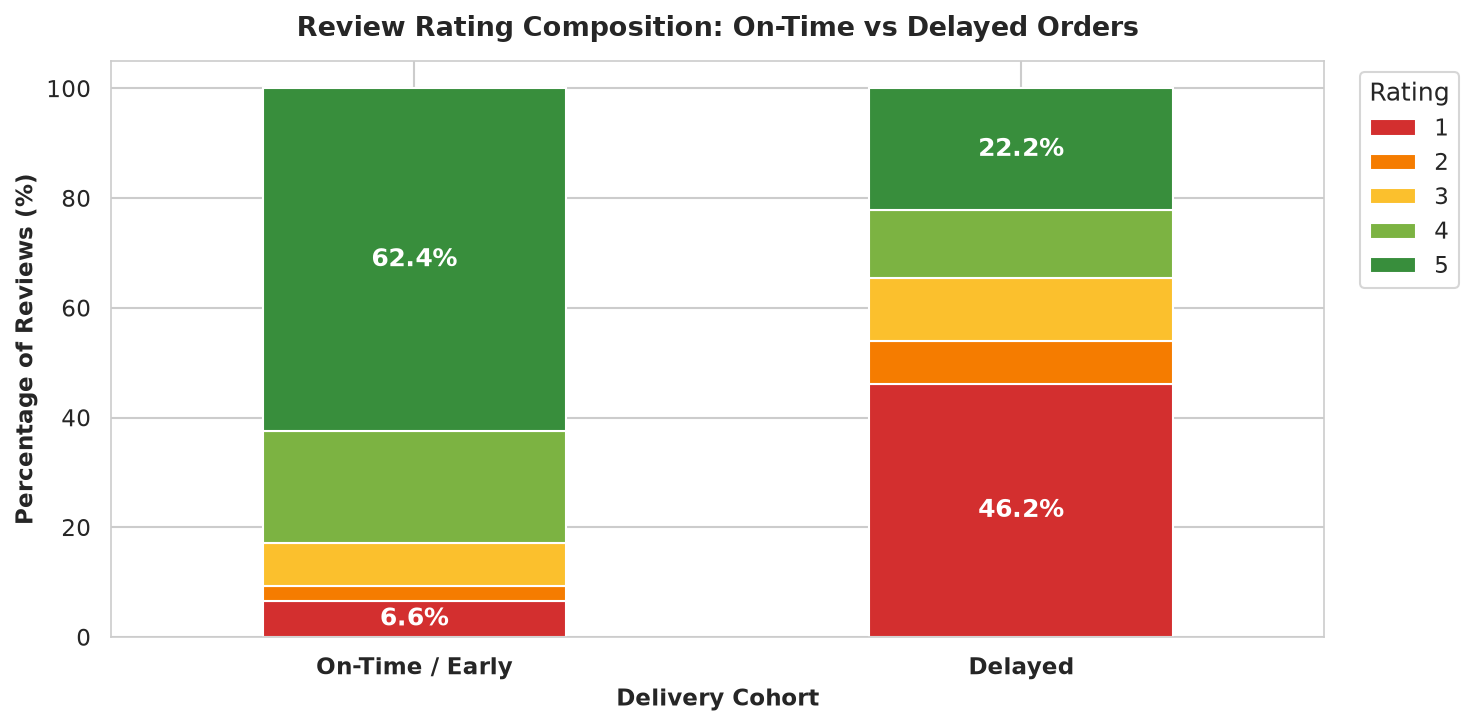

In [7]:
pct_table = pd.crosstab(df['delivery_status'], df['review_score'], normalize='index') * 100
pct_table = pct_table.reindex(['On-Time / Early', 'Delayed'])

colors = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']
ax = pct_table.plot(kind='bar', stacked=True, figsize=(10, 5), color=colors, edgecolor='white')
plt.title('Review Rating Composition: On-Time vs Delayed Orders', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Delivery Cohort', fontsize=11, fontweight='bold')
plt.ylabel('Percentage of Reviews (%)', fontsize=11, fontweight='bold')
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')

for n, c in enumerate(pct_table.index):
    y_1star = pct_table.loc[c, 1] / 2
    ax.text(n, y_1star, f"{pct_table.loc[c, 1]:.1f}%", ha='center', va='center', color='white', fontweight='bold')
    y_5star = 100 - (pct_table.loc[c, 5] / 2)
    ax.text(n, y_5star, f"{pct_table.loc[c, 5]:.1f}%", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('PNG/review_distribution_by_delay.png', dpi=150)
plt.show()


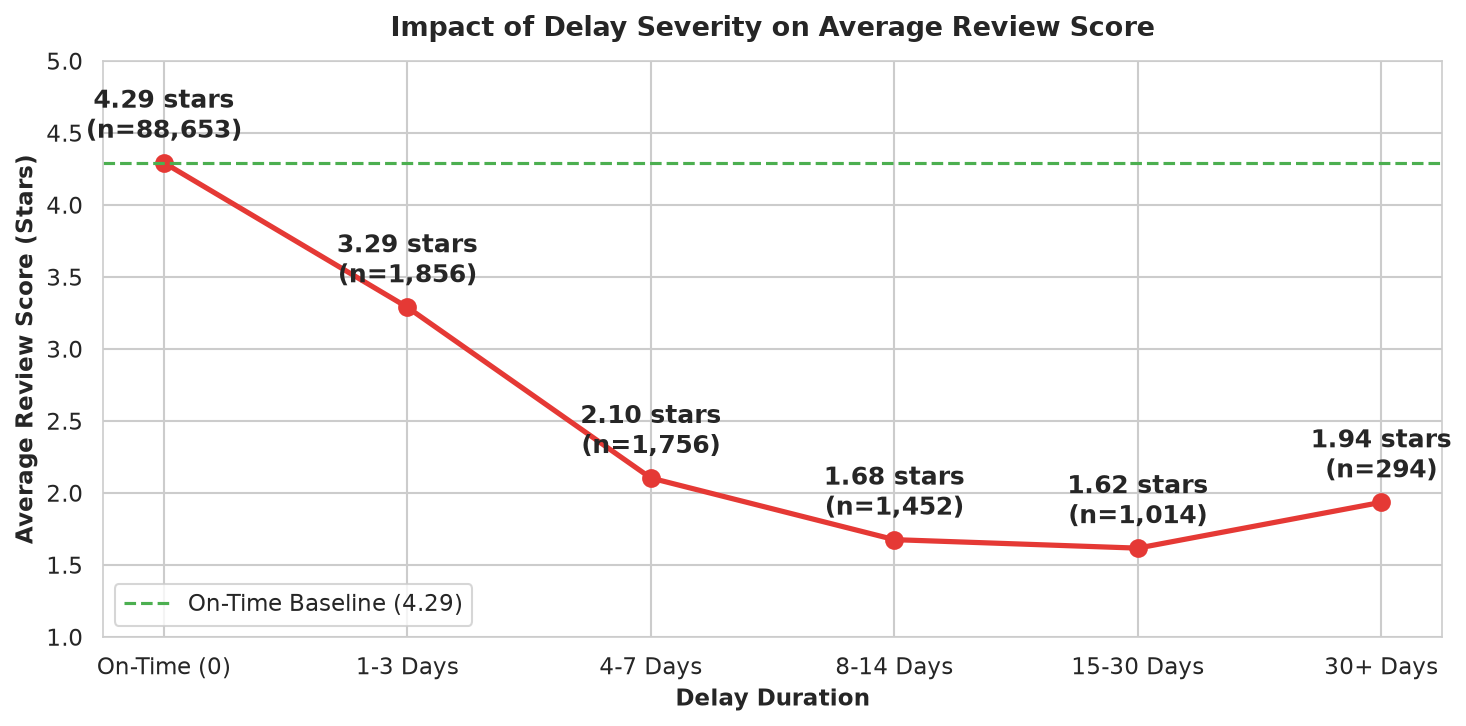

In [8]:
delayed_orders = df[df['is_delayed'] == True].copy()
delayed_orders['delay_bucket'] = pd.cut(
    delayed_orders['delay_days'],
    bins=[0, 3, 7, 14, 30, 100],
    labels=['1-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '30+ Days']
)

severity_summary = delayed_orders.groupby('delay_bucket')['review_score'].agg(['mean', 'count']).reset_index()

on_time_row = pd.DataFrame([{'delay_bucket': 'On-Time (0)', 'mean': ontime.mean(), 'count': len(ontime)}])
severity_summary = pd.concat([on_time_row, severity_summary], ignore_index=True)

plt.figure(figsize=(10, 5))
plt.plot(severity_summary['delay_bucket'], severity_summary['mean'], marker='o', color='#E53935', linewidth=2.5, markersize=8)
plt.axhline(ontime.mean(), color='#4CAF50', linestyle='--', label=f'On-Time Baseline ({ontime.mean():.2f})')
for i, row in severity_summary.iterrows():
    plt.annotate(f"{row['mean']:.2f} stars\n(n={row['count']:,})",
                 (row['delay_bucket'], row['mean']),
                 textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold')

plt.ylim(1.0, 5.0)
plt.title('Impact of Delay Severity on Average Review Score', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Delay Duration', fontsize=11, fontweight='bold')
plt.ylabel('Average Review Score (Stars)', fontsize=11, fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('PNG/review_vs_delay_days.png', dpi=150)
plt.show()
